In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
 # Function representing dy/dx = -2y
def f(x, y):
    return -2 * y


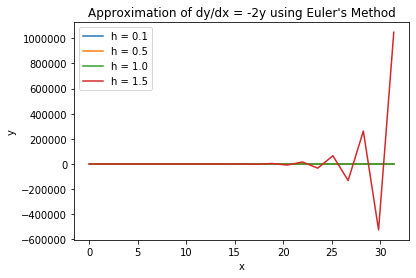

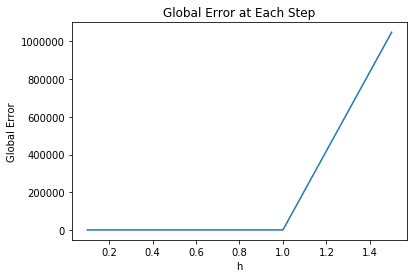

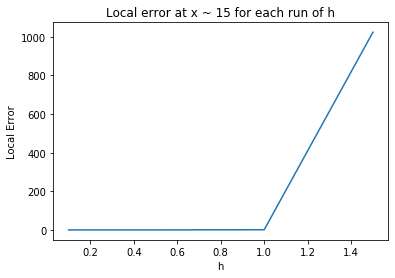


Global error for each run of h
[4.00128947e-02 3.62976573e-01 1.13175199e+00 1.04857600e+06]

Local error at x ~ 15 for each run of h
[8.92557567e-14 6.25688058e-14 1.00000000e+00 1.02400000e+03]


In [27]:
# Step Size
h_values = np.array([.1, .5, 1., 1.5])

# Initalizing arrays to use later
error_list = np.array([])
local_error_list = np.array([])

for h in h_values:
    # Define parameters
    x_start = 0
    x_end = 10 * np.pi
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1  # y(0) = 1
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    # Global Error
    y_exact = np.exp(-2 * x_values)   # The function y' = -2y solved for y
    error = np.abs(y_values - y_exact)
    error_list = np.append(error_list, np.max(error))
    
    # Local Error
    distance_from_15 = np.abs(x_values - 15)
    x_15 = np.argmin(distance_from_15)
    
    local_error = np.abs(y_values[x_15] - y_exact[x_15])
    local_error_list = np.append(local_error_list, local_error)
    
    plt.plot(x_values, y_values, label = f"h = {h}")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

plt.plot(h_values, error_list)
plt.xlabel('h')
plt.ylabel('Global Error')
plt.title("Global Error at Each Step")
plt.show()

plt.plot(h_values, local_error_list)
plt.xlabel('h')
plt.ylabel('Local Error')
plt.title("Local error at x ~ 15 for each run of h")
plt.show()

print("\nGlobal error for each run of h")
print(error_list)
print("\nLocal error at x ~ 15 for each run of h")
print(local_error_list)